<a href="https://colab.research.google.com/github/annaamikom/modern-cnn/blob/main/Hands_On_Resnet_50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Klasifikasi Fast Food dengan ResNet50**
Model ini dibangun untuk melakukan klasifikasi gambar makanan cepat saji (fast food) menggunakan model ResNet50 yang sudah dilatih sebelumnya (pretrained) pada dataset ImageNet. Dengan memanfaatkan teknik transfer learning, kita dapat membangun model klasifikasi yang akurat meskipun dataset relatif terbatas.
<br><br>

### **Dataset**
Dataset yang digunakan berasal dari repositori GitHub:
[Repository Fast Food](https://https://github.com/annaamikom/cnn/tree/main/fast-food-dataset)<br><br>

### **Tujuan**


*   Mengimplementasikan transfer learning dengan arsitektur ResNet50.
*   Melakukan augmentasi data agar model lebih robust terhadap variasi gambar.
*   Melatih model untuk mengenali tiga kategori fast food: Burger, Sandwich, dan Hotdog.
*   Mengevaluasi performa model menggunakan data uji.
*   Menampilkan visualisasi hasil prediksi pada beberapa gambar uji secara acak.


### **Langkah-Langkah**

1. Persiapan dataset: clone dari GitHub, atur struktur folder (train/test).

2. Preprocessing & Augmentasi: scaling, resizing, dan augmentasi data dengan ImageDataGenerator.

3. Pembangunan Model: gunakan ResNet50 pretrained + lapisan tambahan Dense untuk klasifikasi.

4. Training & Validasi: jalankan proses training dengan beberapa epoch dan pantau akurasi/loss.

5. Evaluasi Model: ukur akurasi pada dataset uji.

6. Visualisasi Prediksi: tampilkan hasil prediksi pada gambar uji secara acak.








###**1. Clone Dataset dari GitHub**
Dataset yang digunakan pada latihan ini menggunakan dataset dari: https://github.com/annaamikom/cnn/tree/main/fast-food-dataset

Struktur folder dataset di github :<br>
 fast-food-dataset/<br>
 ├── train/<br>
 │   ├── burger/<br>
 │   ├── sandwich/<br>
 │   └── hotdog/<br>
 └── test/<br>
     ├── burger/<br>
     ├── sandwich/<br>
     └── hotdog/<br>

In [1]:
# 1. Clone Dataset dari GitHub
!git clone https://github.com/annaamikom/cnn.git
%cd cnn/fast-food-dataset

Cloning into 'cnn'...
remote: Enumerating objects: 2125, done.
remote: Counting objects: 100% (2125/2125), done.
remote: Compressing objects: 100% (2122/2122), done.
remote: Total 2125 (delta 10), reused 2105 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (2125/2125), 19.12 MiB | 28.66 MiB/s, done.
Resolving deltas: 100% (10/10), done.
/content/cnn/fast-food-dataset


###**2. Import Library**

In [2]:
# ===== 2. Import Library =====
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

###**3. Read Dataset**

In [3]:
# Read Dataset
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "train",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    "test",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

Found 1500 images belonging to 3 classes.
Found 600 images belonging to 3 classes.


###**4. Load Resnet**

In [4]:
# ===== 4. Load ResNet50 Pretrained =====
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze layer awal


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
#tampilkan arsitektur model Resnet
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

###**5. Konfigurasi Model**

In [7]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(train_generator.num_classes, activation="softmax")
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [8]:
#tampilkan arsitektur model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,371 (90.98 MB)

 Trainable params: 262,659 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

### **6. Training Model**

In [9]:
# 6. Training
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=test_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 394s 8s/step - accuracy: 0.3620 - loss: 1.3507 - val_accuracy: 0.4667 - val_loss: 1.0289
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 386s 8s/step - accuracy: 0.4589 - loss: 1.0336 - val_accuracy: 0.4817 - val_loss: 1.0102
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 377s 8s/step - accuracy: 0.4497 - loss: 1.0217 - val_accuracy: 0.4800 - val_loss: 1.0176
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 376s 8s/step - accuracy: 0.4112 - loss: 1.0495 - val_accuracy: 0.4417 - val_loss: 1.0088
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 378s 8s/step - accuracy: 0.4728 - loss: 1.0193 - val_accuracy: 0.4883 - val_loss: 1.0040


### **7. Evaluasi**

In [10]:
# 7 evaluasi
loss, acc = model.evaluate(test_generator)
print(f"Akurasi data uji: {acc*100:.2f}%")

19/19 ━━━━━━━━━━━━━━━━━━━━ 107s 5s/step - accuracy: 0.4866 - loss: 1.0078
Akurasi data uji: 48.83%


### **8. Visualisasi Performa Model**

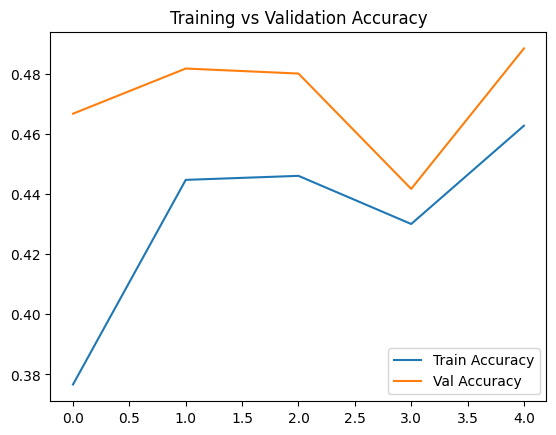

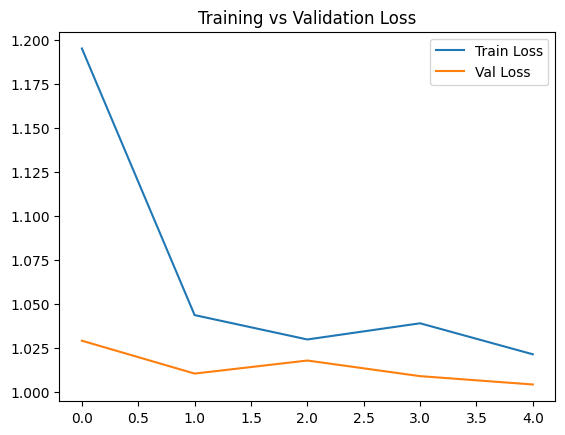

In [11]:
# 8 visualisasi performa model
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()


### **9. Prediksi Data Baru**

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step


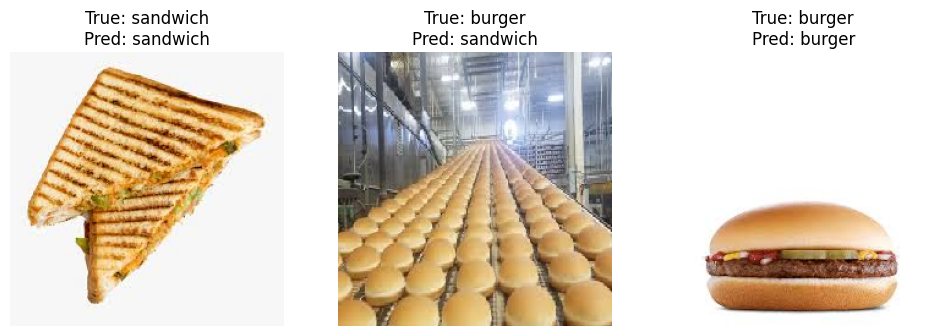

In [12]:
import numpy as np
import random
import matplotlib.pyplot as plt

# ===== 8. Visualisasi Prediksi pada 3 Gambar Random =====
class_labels = list(train_generator.class_indices.keys())

# ambil 3 sample random dari test_generator
x, y = next(test_generator)  # ambil batch pertama
idxs = random.sample(range(len(x)), 3)  # pilih 3 index random

plt.figure(figsize=(12, 4))

for i, idx in enumerate(idxs):
    img = x[idx]
    true_label = class_labels[np.argmax(y[idx])]

    # prediksi
    pred = model.predict(img[np.newaxis, ...])
    pred_label = class_labels[np.argmax(pred)]

    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"True: {true_label}\nPred: {pred_label}")

plt.show()
